<a href="https://colab.research.google.com/github/shikhar11x/Churn_Analysis/blob/main/churn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

## 1.  ***IMPORTING DATABASE***

In [2]:
conn = sqlite3.connect('customer_churn_data.db')

sql_query="""
            SELECT name
            FROM sqlite_master
            WHERE type='table'
"""

tables=pd.read_sql(sql_query,conn)

# create dataframe for each table

for table_name in tables['name']:
    df=pd.read_sql(f"SELECT * FROM {table_name}",conn)
    globals()[f"df_{table_name}"]=df
    print(f"Created dataframes: df_{table_name}")

conn.close()


Created dataframes: df_db_customer
Created dataframes: df_db_subscription
Created dataframes: df_db_support


In [3]:
# print tables name and column names
conn=sqlite3.connect('customer_churn.db')
for table_name in tables['name']:
  print(f"\nTable: {table_name}")

  # Get column information
  columns_query=f"PRAGMA table_info({table_name});"
  columns=pd.read_sql(columns_query,conn)
  print("Columns:")
  print(columns['name'].tolist())

conn.close()


Table: db_customer
Columns:
[]

Table: db_subscription
Columns:
[]

Table: db_support
Columns:
[]


## 2. ***DATA CLEANING***

In [4]:
# 1st table df_db_customer

In [5]:
# df_db_customer.head()
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
10016,8799-LQINK,seema,India,Karnataka,Male,1989-01-19 00:00:00,None,None
10017,7329-FPLTE,swati,India,Karnataka,Male,1980-05-28 00:00:00,movie,None
10018,8314-EVJME,lata,India,Uttar Pradesh,Male,2003-09-09 00:00:00,job,None
10019,3897-OSTRM,nisha,India,Rajasthan,Men,1997-11-20 00:00:00,None,None
10020,7602-ZOTLL,komal,India,Rajasthan,Male,2003-09-27 00:00:00,None,None


In [6]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10021 entries, 0 to 10020
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  10021 non-null  object
 1   name        10021 non-null  object
 2   country     9002 non-null   object
 3   state       10021 non-null  object
 4   gender      10021 non-null  object
 5   dob         10021 non-null  object
 6   interests   5716 non-null   object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 626.4+ KB


In [7]:
# ---- GOALS ----
# a. rename columne name
# b. drop columns - intest and pincode
# c. change datatype of dob
# d. Data standardization in gender
# e. fix missing values in country

In [8]:
# Rename
df_db_customer.rename(columns={'name' : 'customer_name'},inplace=True)
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
...,...,...,...,...,...,...,...,...
10016,8799-LQINK,seema,India,Karnataka,Male,1989-01-19 00:00:00,None,None
10017,7329-FPLTE,swati,India,Karnataka,Male,1980-05-28 00:00:00,movie,None
10018,8314-EVJME,lata,India,Uttar Pradesh,Male,2003-09-09 00:00:00,job,None
10019,3897-OSTRM,nisha,India,Rajasthan,Men,1997-11-20 00:00:00,None,None


In [9]:
# Drop tables

# df_db_customer.drop(df_db_customer.columns[-2:],axis=1)

df_db_customer.drop(columns=['interests','pincode'],inplace=True)


In [10]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10021 entries, 0 to 10020
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     10021 non-null  object
 1   customer_name  10021 non-null  object
 2   country        9002 non-null   object
 3   state          10021 non-null  object
 4   gender         10021 non-null  object
 5   dob            10021 non-null  object
dtypes: object(6)
memory usage: 469.9+ KB


In [11]:
# change data type of DOB

df_db_customer['dob']=pd.to_datetime(df_db_customer['dob'])


In [12]:
# Data Standardization of gender
df_db_customer['gender'].unique()

array(['Male', 'Female', 'Women', 'Men'], dtype=object)

In [13]:
df_db_customer['gender']=df_db_customer['gender'].replace({'Men':'Male','Women':'Female'})


In [14]:
df_db_customer['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [15]:
# fix missing value
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01
30,0888-RZCKI,ramesh,None,Telangana,Female,1981-04-15
31,3503-WXEAK,usha,None,Telangana,Female,1981-12-11
...,...,...,...,...,...,...
9984,5094-DRSOI,ramesh,None,Karnataka,Male,1980-10-08
9991,6825-ONRJO,Tarun,None,Kathmandu,Female,2003-01-27
9995,1020-MTSVT,dinesh,None,Kathmandu,Female,1975-02-11
9999,8069-TVVYU,amit,None,Karnataka,Male,1990-02-06


In [16]:
df_db_customer[['country','state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
...,...,...
10016,India,Karnataka
10017,India,Karnataka
10018,India,Uttar Pradesh
10019,India,Rajasthan


In [17]:
state_country_mapping=df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_db_customer['country']=df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [18]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [19]:
# 2nd table df_db_subscription

In [20]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [21]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10021 entries, 0 to 10020
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               10021 non-null  object 
 1   subscription_start_date  10021 non-null  object 
 2   subscription_type        10021 non-null  object 
 3   renewal_date             10021 non-null  object 
 4   plan_type                10021 non-null  object 
 5   contract_type            10021 non-null  object 
 6   cancellation_date        3795 non-null   object 
 7   cancellation_reason      3795 non-null   object 
 8   monthly_charges          10021 non-null  float64
 9   cltv                     10021 non-null  int64  
 10  churn_score              10021 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 861.3+ KB


In [22]:
date_col =['subscription_start_date','renewal_date',"cancellation_date"]
df_db_subscription[date_col]= df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10021 entries, 0 to 10020
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               10021 non-null  object        
 1   subscription_start_date  10021 non-null  datetime64[ns]
 2   subscription_type        10021 non-null  object        
 3   renewal_date             10021 non-null  datetime64[ns]
 4   plan_type                10021 non-null  object        
 5   contract_type            10021 non-null  object        
 6   cancellation_date        3795 non-null   datetime64[ns]
 7   cancellation_reason      3795 non-null   object        
 8   monthly_charges          10021 non-null  float64       
 9   cltv                     10021 non-null  int64         
 10  churn_score              10021 non-null  int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 861.3+ KB


In [23]:
# 3rd table

In [24]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [25]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4646 entries, 0 to 4645
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      4646 non-null   object
 1   complaint_date  4646 non-null   object
 2   escalations     4646 non-null   object
 3   csat_score      4646 non-null   int64 
 4   col_1           0 non-null      object
 5   comment         3158 non-null   object
dtypes: int64(1), object(5)
memory usage: 217.9+ KB


In [26]:
df_db_support.drop(columns=['col_1','comment'],inplace=True)

In [27]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

In [28]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4646 entries, 0 to 4645
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      4646 non-null   object        
 1   complaint_date  4646 non-null   datetime64[ns]
 2   escalations     4646 non-null   object        
 3   csat_score      4646 non-null   int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 145.3+ KB


DATA CLEANING DONE ✅

### ***FEATURE ENGINEERING AND DATA ANALYSIS***

Creating a new column for churn flag to identify customers who have churned.

In [29]:
df_db_subscription['churn_flag']=np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [30]:

df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [31]:
df_db_subscription.shape

(10021, 12)

In [32]:
df_db_subscription['customerid'].nunique()

10021

In [33]:
df_db_customer['customerid'].nunique()

10021

In [34]:
df_db_support['customerid'].nunique()

3494

In [35]:
df_db_support['customerid'].size

4646

In [36]:
df_db_support


,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
...,...,...,...,...
4641,9736-SHHIN,2026-05-12,Y,16
4642,1254-SYVQL,2025-02-28,N,38
4643,1020-MTSVT,2022-01-13,N,41
4644,8069-TVVYU,2025-09-21,N,40


In [37]:
df_db_support['complaint_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [38]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
...,...,...,...,...,...
4641,9736-SHHIN,2026-05-12,Y,16,2
4642,1254-SYVQL,2025-02-28,N,38,1
4643,1020-MTSVT,2022-01-13,N,41,1
4644,8069-TVVYU,2025-09-21,N,40,1


In [39]:
df_db_support=df_db_support.sort_values('complaint_date').drop_duplicates("customerid",keep='last')

In [40]:
df_db_support.shape

(3494, 5)

In [41]:
# merging tables
df= (df_db_subscription
              .merge(df_db_customer, on='customerid',how='left')
              .merge(df_db_support, on='customerid',how='left')

 )

In [42]:
df.shape

(10021, 21)

In [43]:
df.to_csv('exported_churn_data.csv',index=False)

## ***DATA ANALYSIS***

1.  churn Rate

In [44]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [45]:
churn_rate=df['churn_flag'].mean()*100
print('Churn rate = ',round(churn_rate,2),'%')

Churn rate =  37.87 %


2. Retension Rate

In [46]:
retension_rate=100-churn_rate
print('Retension rate = ',round(retension_rate,2),'%')

Retension rate =  62.13 %


3. Churn by Plan Type

In [47]:
churn_by_plan=(df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2)
.reset_index(name='churn_rate_pct'))

print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           38.26
1   Premium           36.65
2  Standard           38.65


4. Avg Revenue per user - ARPU

In [48]:
arpu=df['monthly_charges'].mean()
print("ARPU = ",round(arpu,2),"₹")

ARPU =  20.16 ₹


5. Avg tenure

In [49]:
today=pd.Timestamp.today()

df['tenure_days']=np.where(
    df['cancellation_date'].notna(),
     (df['cancellation_date']-df['subscription_start_date']).dt.days,
    (today-df['subscription_start_date']).dt.days
)
avg_tenure =df['tenure_days'].mean()
print("Avg tenure = ",avg_tenure)

Avg tenure =  1428.043408841433


6. Revenue loss at risk

In [50]:
revenue_at_risk=df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print("Revenue At risk =",revenue_at_risk)

Revenue At risk = 76108.05000000002


7. Esclation **Rate**

In [51]:
escalations_rate =(df['escalations']== 'Y').mean()*100
print("Escalations Rate = ",round(escalations_rate,2))

Escalations Rate =  17.65


8. Avg complaint Rate

In [52]:
avg_complaints=df['complaint_count'].sum() /df['customerid'].nunique()

print("Avg Complaint rate =",round(avg_complaints,2))

Avg Complaint rate = 0.46


9. Correlation Esclation vs churn

In [53]:
df['escalations']=np.where(df['escalations']=='Y',1,0)  #ecoding string to int

In [54]:
corr_df=df[['escalations','churn_flag']].dropna()

correlation=corr_df['escalations'].corr(df['churn_flag'])
print("Correlation between escalations and churn = ",round(correlation,2))

Correlation between escalations and churn =  0.01


10. Churn Risk

In [55]:
condition=[
    (df['churn_score']<50),
    (df['churn_score']>=50) & (df['churn_score']<70),
    (df['churn_score']>=70)
]

choices=['low','medium','high']

df['churn_risk']=np.select(condition,choices,default='unknown')

In [56]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,1941.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,0,60.0,2.0,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1326.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2616.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,high


# 4. ***Visualization Using MatplotLib***

In [57]:
df_visual=df.copy()

In [58]:
df_visual.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,1941.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,0,60.0,2.0,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1326.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2616.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,high


In [59]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

4.1 Monthly Churn Trend (Time Series KPI)

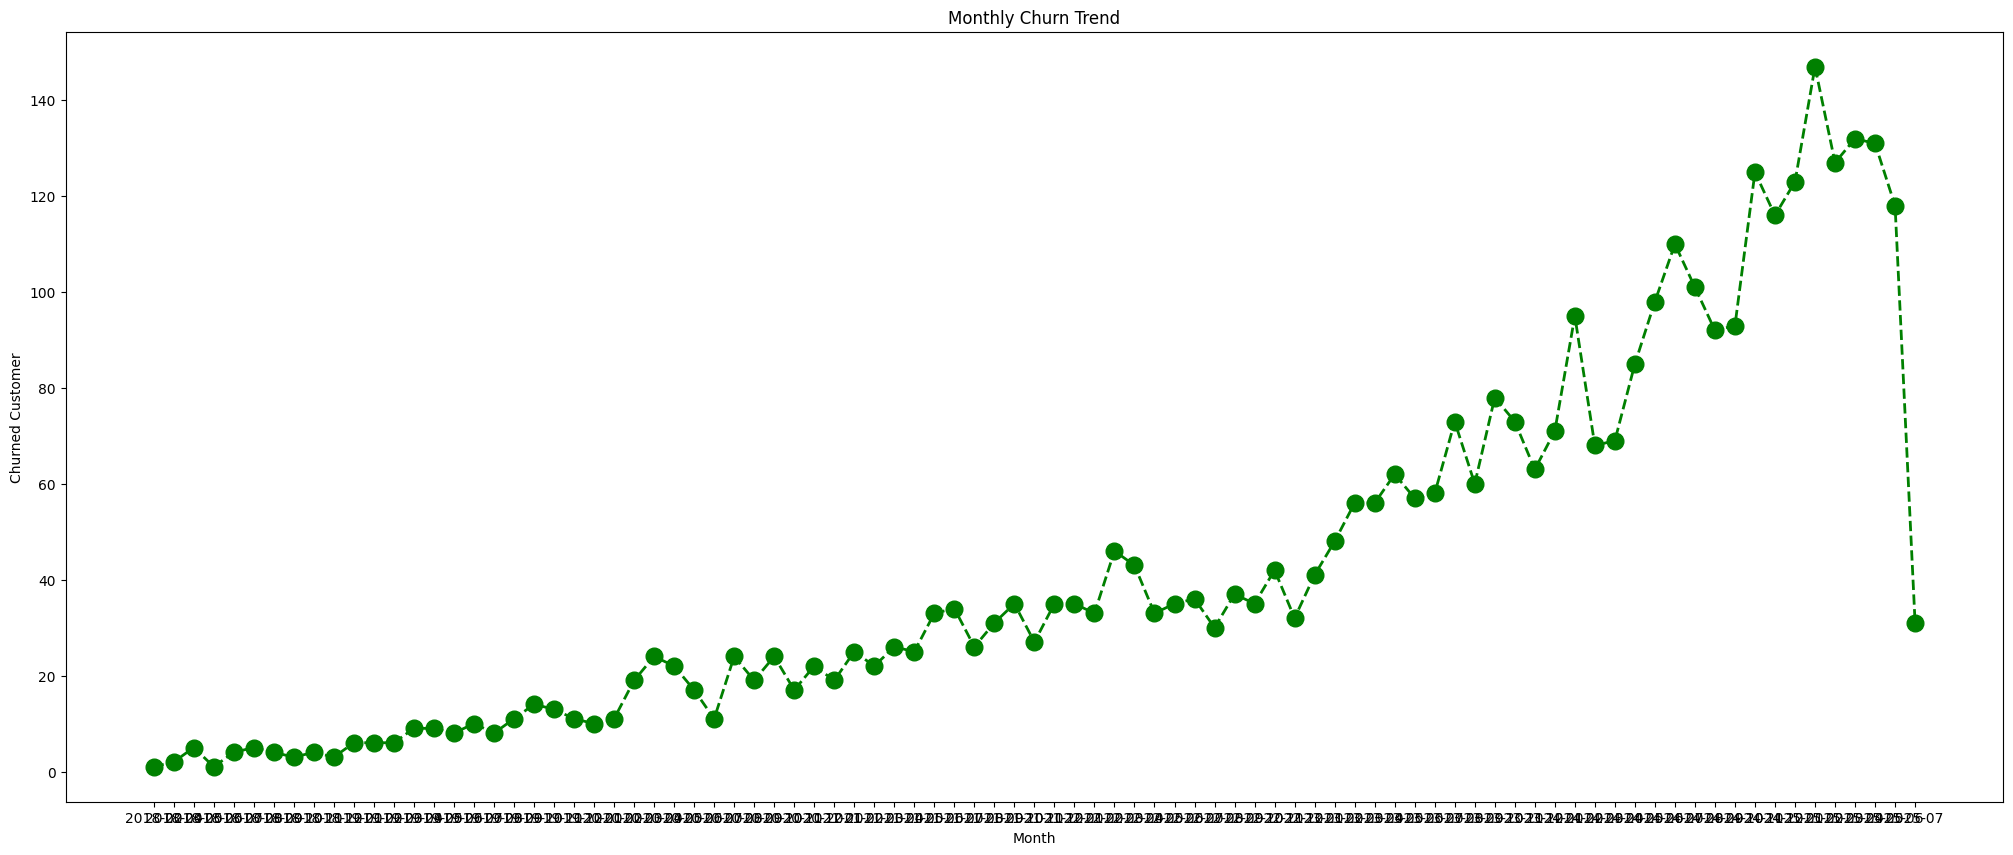

In [60]:
df_visual['cancellation_month']=df_visual['cancellation_date'].dt.to_period('M')

churn_trend=df_visual[df_visual['churn_flag']==1].groupby('cancellation_month').size()


plt.figure(figsize=(25,10))
plt.plot(churn_trend.index.astype(str), churn_trend.values,color='green',marker='o',linestyle='dashed',linewidth=2,markersize=12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customer')
plt.show()


4.2 Churn by plan type

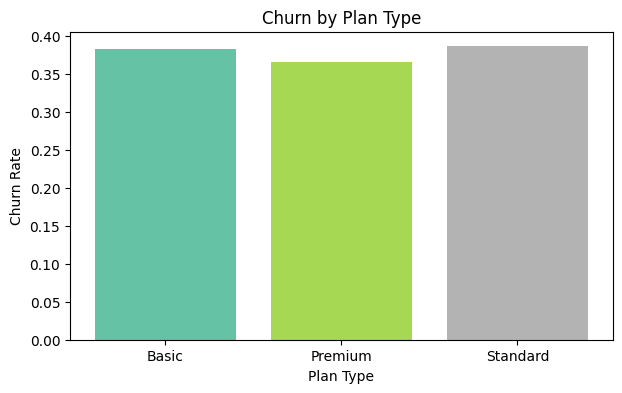

In [61]:
churn_plan=df_visual.groupby('plan_type')['churn_flag'].mean()

colors=plt.cm.Set2(np.linspace(0,1,len(churn_plan)))

plt.figure(figsize=(7,4))
plt.bar(churn_plan.index,churn_plan.values,color=colors)
plt.title('Churn by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate')
plt.show()

4.3 Churn by state



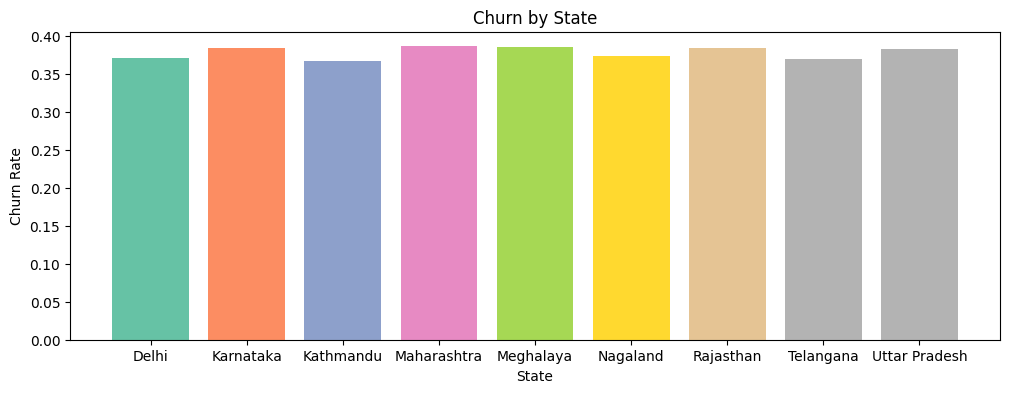

In [62]:
churn_plan=df_visual.groupby('state')['churn_flag'].mean()

colors=plt.cm.Set2(np.linspace(0,1,len(churn_plan)))

plt.figure(figsize=(12,4))
plt.bar(churn_plan.index,churn_plan.values,color=colors)
plt.title('Churn by State')
plt.xlabel('State')
plt.ylabel('Churn Rate')
plt.show()

# **5. Visualization using Seaborn**

5.1 Heatmap (correlation matrix)

In [63]:
# encoding converting str to numeric so that we can find corr between features
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [64]:
df_visual[[  'plan_type', 'contract_type', 'churn_score',
       'churn_flag','churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,0
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [65]:
df_encoder=df_visual[[  'plan_type', 'contract_type', 'churn_score',
       'churn_flag','churn_risk', 'escalations']].head()
order_mapping={
    'plan_type':['Basic','Standard','Premium'],
    'contract_type':['Monthly','Annual'],
    'churn_risk':['low', 'medium','high']}

for col,order in order_mapping.items():
  df_encoder[col]=pd.Categorical(df_encoder[col].astype('category'),categories=order,ordered=True).codes

In [66]:
df_encoder.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,0
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


In [67]:
# # incorrect method
# df_encoder=df_visual[[  'plan_type', 'contract_type', 'churn_score',
#        'churn_flag','churn_risk', 'escalations']].head()
# categorial_cols=['plan_type','contract_type','churn_risk']

# for col in categorial_cols:
#   df_encoder[col]=df_encoder[col].astype('category').cat.codes


In [68]:
df_visual['churn_risk'].unique()

array(['low', 'high', 'medium'], dtype=object)

In [69]:
df_visual[[  'plan_type', 'contract_type', 'churn_score',
       'churn_flag','churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,0
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [70]:
df_encoder.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,0
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


<Axes: >

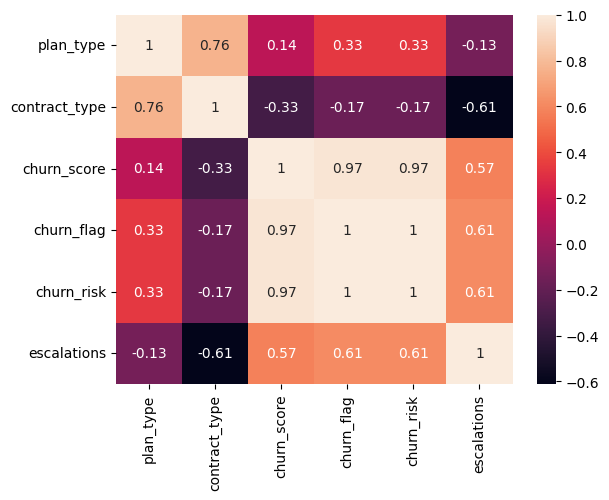

In [71]:
sns.heatmap(df_encoder.corr(),annot=True,)

5.2 PairPlot


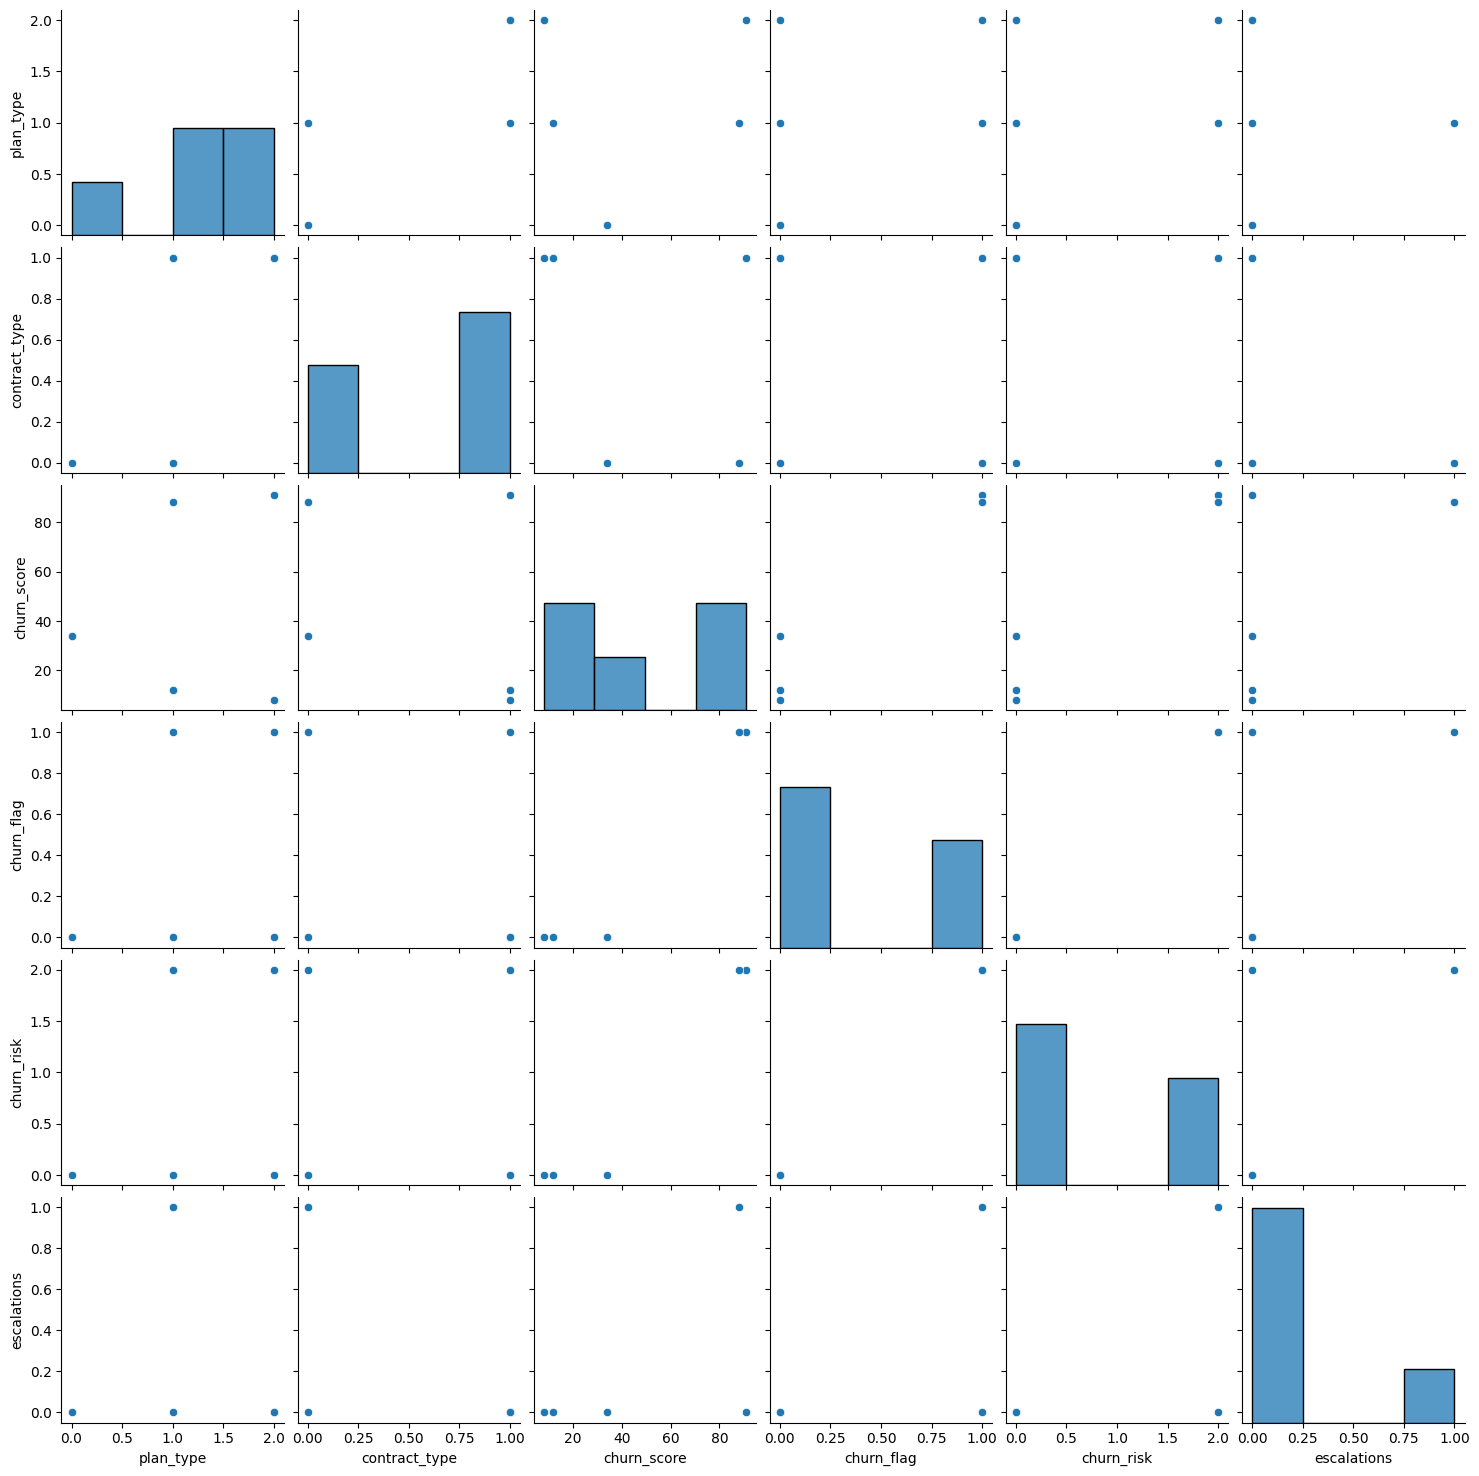

In [73]:
sns.pairplot(df_encoder)

5.3 Catplot/facegrid

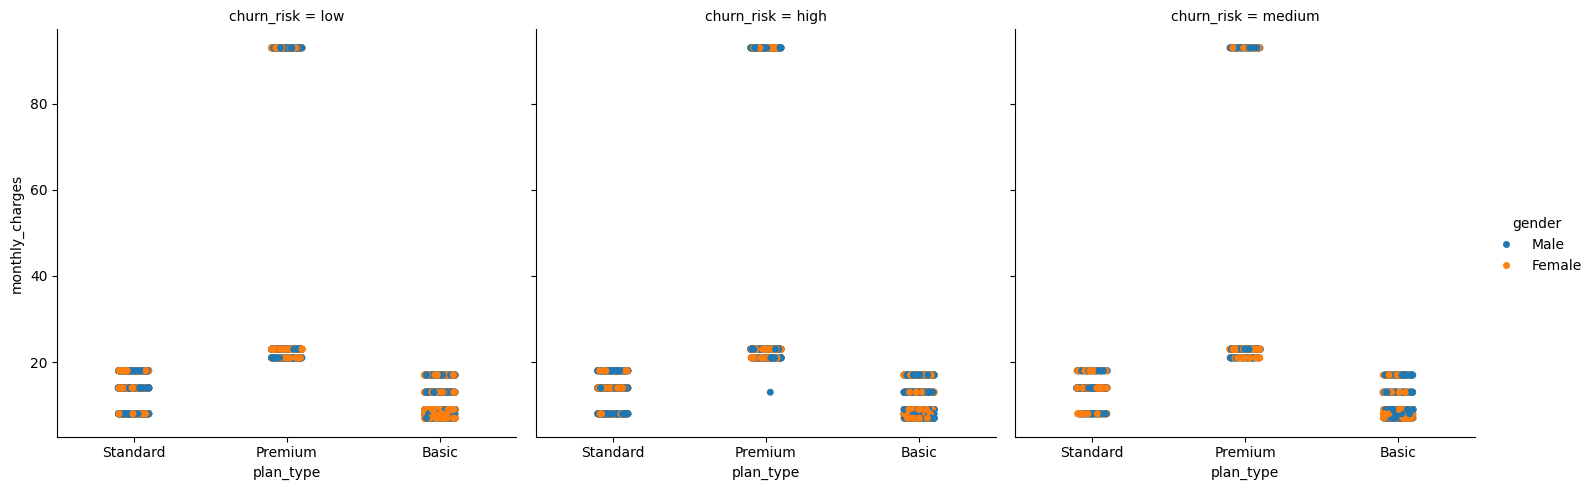

In [76]:
sns.catplot(data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk'
)

# **6. Pivot Table**

in pandas python

In [77]:
pd.pivot_table(
    data=df_visual,
    values='churn_flag',
    index='plan_type',
    aggfunc='mean'

)

,churn_flag
plan_type,
Basic,0.382624
Premium,0.366483
Standard,0.386537


In [80]:
pd.pivot_table(
    data=df_visual,
    index='plan_type',
    values=['monthly_charges','customerid','churn_flag'],
    aggfunc={
        'monthly_charges':'sum',
        'customerid':'nunique',
        'churn_flag':'mean'
    }

)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.382624,3361,36298.39
Premium,0.366483,3258,119503.42
Standard,0.386537,3402,46211.98
